# SVHN 图像分类作业：基于 CNN 的完整技术实现

本 Notebook 按照作业要求完成 **SVHN Format 2（32×32 RGB）** 的 10 类数字分类任务，整体流程对应题目 PDF 中给出的实现路线：**初始化全局变量 → 构建数据集 → 构建模型 → 构建优化器与损失函数 → 构建训练循环 → 结果可视化 → 保存模型**。  
同时补充了研究生层次更完整的实验设计，包括：

- 数据读取与标签修正
- 训练/验证/测试集划分
- 数据增强与标准化
- 基础 CNN 与增强版 CNN
- 训练日志记录
- 损失曲线与准确率曲线
- 混淆矩阵与分类报告
- 最优模型保存与加载
- 错分样本可视化

> 说明：  
> 1. 该 Notebook 默认使用 `train_32x32.mat` 与 `test_32x32.mat`。  
> 2. SVHN 原始标签中 **数字 0 被标为 10**，因此需要在预处理阶段映射回 `0`。  
> 3. 建议在 GPU 环境运行。  
> 4. 你可以直接在每个 Markdown 单元补充自己的实验分析后，再导出 PDF。

## 1. 技术实现路线

结合题目要求，完整技术路线如下：

### 1.1 数据准备
- 下载 `train_32x32.mat` 与 `test_32x32.mat`
- 使用 `scipy.io.loadmat` 读取 `.mat` 文件
- 将数据从 `(H, W, C, N)` 变换为 `(N, H, W, C)`
- 将标签中的 `10` 映射为 `0`
- 从训练集划分出一部分作为验证集

### 1.2 数据预处理
- 将图像转换为 `float32`
- 训练集使用轻量数据增强：
  - 随机裁剪
  - 随机旋转
  - 颜色扰动（可选）
- 全部数据进行 `ToTensor + Normalize`

### 1.3 模型设计
- 采用 CNN 作为基础模型，满足作业基本要求
- 网络结构包含：
  - 多层卷积 + BatchNorm + ReLU
  - 最大池化降低空间维度
  - Dropout 抑制过拟合
  - 全连接层输出 10 类概率
- 为了提升性能，代码中给出一个**较强但仍适合课程作业**的 CNN

### 1.4 模型训练
- 损失函数：`CrossEntropyLoss`
- 优化器：`AdamW`
- 学习率调度：`ReduceLROnPlateau`
- 每个 epoch 统计：
  - Train Loss
  - Train Accuracy
  - Val Loss
  - Val Accuracy

### 1.5 模型评估
- 在测试集上计算：
  - Test Accuracy
  - Test Loss
- 绘制：
  - 训练/验证损失曲线
  - 训练/验证准确率曲线
- 进一步分析：
  - 混淆矩阵
  - 分类报告
  - 错分样本展示

### 1.6 模型保存与结果整理
- 保存验证集表现最优的模型参数
- 在测试集上载入最优模型进行最终评估
- 将关键结果图用于报告撰写

In [21]:
# =========================
# 2. 环境与依赖
# =========================

import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

import scipy.io as sio
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.1.0
CUDA available: True


In [22]:
# =========================
# 3. 全局配置
# =========================

SEED = 42
DATA_DIR = Path("./data")
TRAIN_MAT = DATA_DIR / "train_32x32.mat"
TEST_MAT = DATA_DIR / "test_32x32.mat"
MODEL_DIR = Path("./checkpoints")
FIG_DIR = Path("./figures")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 128
# Windows 的 Notebook 环境下，先用 0 个 worker 保证稳定并减少启动开销
NUM_WORKERS = 0
NUM_CLASSES = 10
EPOCHS = 40
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
VAL_RATIO = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print("Using device:", DEVICE)

Using device: cuda


## 2. 读取 SVHN `.mat` 数据并完成标签修正

SVHN 的 `.mat` 文件中：
- 图像维度通常为 `(32, 32, 3, N)`
- 标签维度通常为 `(N, 1)`
- 标签中的 `10` 实际表示数字 `0`

因此需要把数据转成常见的 `(N, 32, 32, 3)` 形式，并把标签 `10 -> 0`。

In [23]:
# =========================
# 4. 数据读取函数
# =========================

def load_svhn_mat(mat_path):
    data = sio.loadmat(mat_path)
    X = data["X"]                     # (32, 32, 3, N)
    y = data["y"].astype(np.int64)   # (N, 1)

    X = np.transpose(X, (3, 0, 1, 2))   # -> (N, 32, 32, 3)
    y = y.squeeze()

    # SVHN 中标签 10 表示数字 0
    y[y == 10] = 0
    return X, y

assert TRAIN_MAT.exists(), f"未找到训练集文件: {TRAIN_MAT}"
assert TEST_MAT.exists(), f"未找到测试集文件: {TEST_MAT}"

X_train_full, y_train_full = load_svhn_mat(TRAIN_MAT)
X_test, y_test = load_svhn_mat(TEST_MAT)

print("Train full:", X_train_full.shape, y_train_full.shape)
print("Test:", X_test.shape, y_test.shape)
print("Train label range:", np.unique(y_train_full))
print("Test label range:", np.unique(y_test))

Train full: (73257, 32, 32, 3) (73257,)
Test: (26032, 32, 32, 3) (26032,)
Train label range: [0 1 2 3 4 5 6 7 8 9]
Test label range: [0 1 2 3 4 5 6 7 8 9]


In [24]:
# =========================
# 5. 划分训练集 / 验证集
# =========================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VAL_RATIO,
    random_state=SEED,
    stratify=y_train_full
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (65931, 32, 32, 3) (65931,)
Val: (7326, 32, 32, 3) (7326,)
Test: (26032, 32, 32, 3) (26032,)


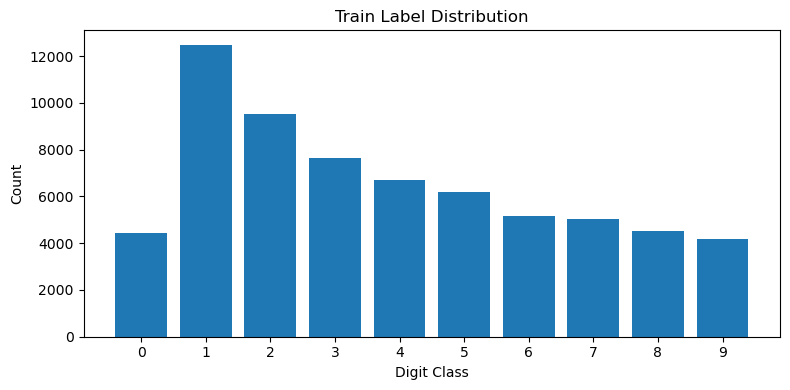

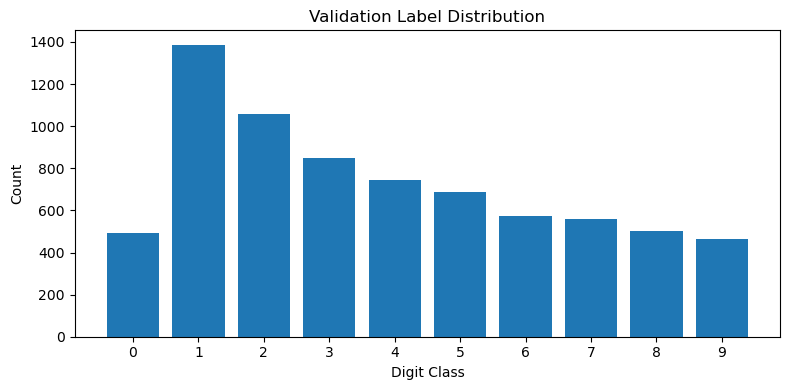

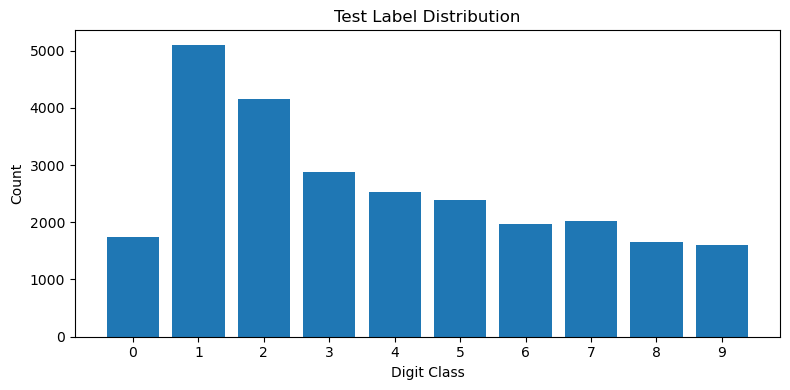

In [25]:
# =========================
# 6. 查看类别分布
# =========================

def plot_label_distribution(labels, title, save_path=None):
    counts = np.bincount(labels, minlength=10)
    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(10), counts)
    plt.xticks(np.arange(10))
    plt.xlabel("Digit Class")
    plt.ylabel("Count")
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

plot_label_distribution(y_train, "Train Label Distribution", FIG_DIR / "train_label_distribution.png")
plot_label_distribution(y_val, "Validation Label Distribution", FIG_DIR / "val_label_distribution.png")
plot_label_distribution(y_test, "Test Label Distribution", FIG_DIR / "test_label_distribution.png")

### 结果分析建议
这里可以分析训练集、验证集和测试集的类别分布是否相对均衡。  
SVHN 各类别一般不会完全平均，但整体上不存在极端失衡，因此可以直接采用普通交叉熵损失进行训练。

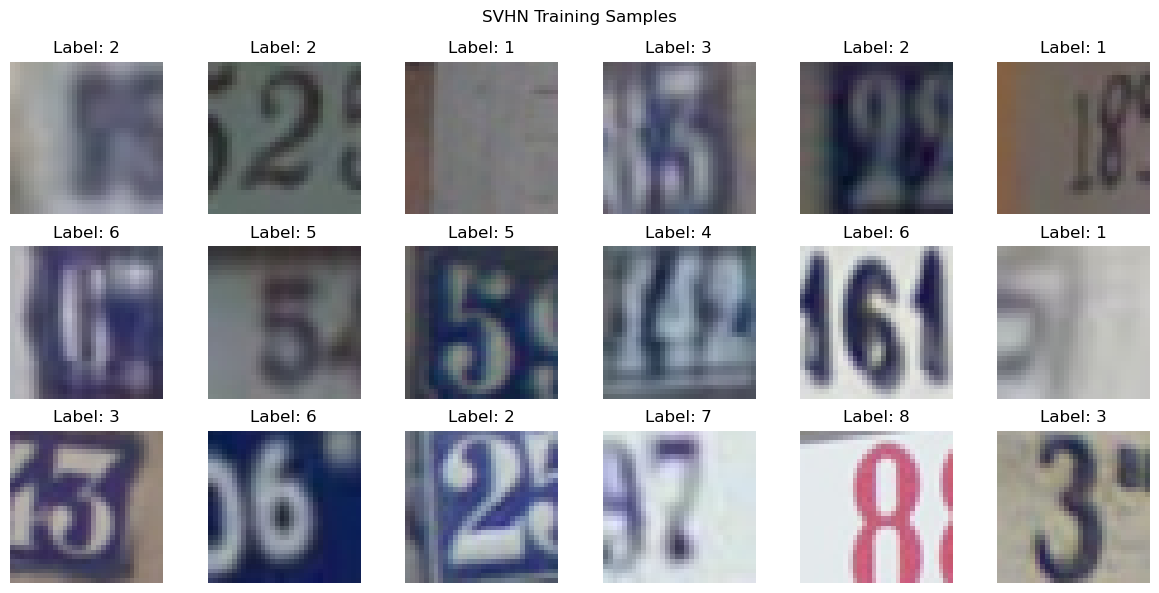

In [26]:
# =========================
# 7. 可视化样本
# =========================

def show_samples(images, labels, rows=3, cols=6, title="Sample Images"):
    plt.figure(figsize=(cols * 2, rows * 2))
    indices = np.random.choice(len(images), rows * cols, replace=False)
    for i, idx in enumerate(indices, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(images[idx])
        plt.title(f"Label: {labels[idx]}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(X_train, y_train, title="SVHN Training Samples")

## 3. 构建数据集与数据加载器

由于数据已经加载到内存中，因此这里自定义 `Dataset`，再配合 `DataLoader` 完成批量读取。  
训练集与验证/测试集的变换策略不同：

- **训练集**：加入轻量增强，提高泛化能力
- **验证/测试集**：仅做张量化和归一化，保证评估稳定性

In [27]:
# =========================
# 8. 自定义 Dataset
# =========================

class SVHNDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = int(self.labels[idx])

        # 转为 PIL 之前可以直接给 transforms.ToPILImage 处理 ndarray
        if self.transform:
            image = self.transform(image)
        else:
            image = transforms.ToTensor()(image)

        return image, label

In [28]:
# =========================
# 9. 数据增强与归一化
# =========================

# 一个常用经验值；也可以先统计训练集均值方差再替换
mean = [0.4377, 0.4438, 0.4728]
std = [0.1980, 0.2010, 0.1970]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomCrop(32, padding=4),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_dataset = SVHNDataset(X_train, y_train, transform=train_transform)
val_dataset = SVHNDataset(X_val, y_val, transform=test_transform)
test_dataset = SVHNDataset(X_test, y_test, transform=test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

len(train_loader), len(val_loader), len(test_loader)

(516, 58, 204)

## 4. 设计 CNN 模型

为了满足作业“CNN 是基本要求”的条件，这里给出一个较完整的卷积网络。结构设计思路如下：

1. 采用多层卷积提取局部纹理和数字结构特征  
2. 使用 `BatchNorm` 提升训练稳定性  
3. 使用 `ReLU` 引入非线性  
4. 使用 `MaxPool2d` 逐步降低空间维度  
5. 使用 `Dropout` 缓解过拟合  
6. 最后通过全连接层输出 10 类 logits  

该结构相较于最基础的两层 CNN 更稳健，适合作为课程作业中的“加强版 CNN”实现。

In [29]:
# =========================
# 10. CNN 模型
# =========================

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.block(x)

class SVHNCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 32, dropout=0.10),   # 32x32 -> 16x16
            ConvBlock(32, 64, dropout=0.15),  # 16x16 -> 8x8
            ConvBlock(64, 128, dropout=0.20), # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SVHNCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(model)

SVHNCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), 

In [30]:
# 统计参数量
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Trainable parameters: {count_parameters(model):,}")

Trainable parameters: 814,570


### 模型设计分析建议
可在报告中说明：
- 小尺寸图像（32×32）更适合采用 3×3 卷积核堆叠；
- 多层卷积能够逐步从低级边缘纹理过渡到高级数字形状特征；
- BatchNorm 与 Dropout 分别从训练稳定性和泛化性能角度提升模型表现。

In [31]:
# =========================
# 11. 损失函数、优化器、学习率调度器
# =========================

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2,
    verbose=True
)

print(criterion)
print(optimizer)

CrossEntropyLoss()
AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


## 5. 训练与验证函数

为了使 Notebook 结构清晰，下面把单轮训练、单轮验证、完整训练循环分别封装为函数。  
每个 epoch 都会记录：

- 平均损失
- 分类准确率
- 当前学习率

并根据验证集损失保存最优模型。

In [32]:
# =========================
# 12. 训练 / 验证函数
# =========================

def compute_accuracy(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    total = targets.size(0)
    return correct / total

def train_one_epoch(model, dataloader, criterion, optimizer, device, epoch=None, total_epochs=None, log_every=50):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    total_batches = len(dataloader)
    for batch_idx, (images, labels) in enumerate(dataloader, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

        if batch_idx % log_every == 0 or batch_idx == total_batches:
            avg_loss = running_loss / running_total
            avg_acc = running_correct / running_total
            if epoch is not None and total_epochs is not None:
                print(
                    f"  Epoch [{epoch:02d}/{total_epochs}] Batch [{batch_idx:03d}/{total_batches:03d}] "
                    f"Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}",
                    flush=True,
                )
            else:
                print(
                    f"  Batch [{batch_idx:03d}/{total_batches:03d}] Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}",
                    flush=True,
                )

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate(model, dataloader, criterion, device, log_every=0):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    all_preds = []
    all_labels = []

    total_batches = len(dataloader)
    for batch_idx, (images, labels) in enumerate(dataloader, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if log_every and (batch_idx % log_every == 0 or batch_idx == total_batches):
            avg_loss = running_loss / running_total
            avg_acc = running_correct / running_total
            print(
                f"  Eval Batch [{batch_idx:03d}/{total_batches:03d}] Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}",
                flush=True,
            )

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds)

In [33]:
# =========================
# 13. 完整训练循环
# =========================

history = defaultdict(list)
best_val_loss = float("inf")
best_model_path = MODEL_DIR / "best_svhn_cnn.pth"

for epoch in range(1, EPOCHS + 1):
    print(f"\nStarting epoch {epoch}/{EPOCHS} ...", flush=True)
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        epoch=epoch, total_epochs=EPOCHS, log_every=50
    )
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"  -> Best model saved to: {best_model_path}")

print("Training finished.")


Starting epoch 1/40 ...
  Epoch [01/40] Batch [050/516] Loss: 2.3058 | Acc: 0.1737
  Epoch [01/40] Batch [100/516] Loss: 2.2794 | Acc: 0.1805
  Epoch [01/40] Batch [150/516] Loss: 2.2684 | Acc: 0.1846
  Epoch [01/40] Batch [200/516] Loss: 2.2587 | Acc: 0.1838
  Epoch [01/40] Batch [250/516] Loss: 2.2430 | Acc: 0.1856
  Epoch [01/40] Batch [300/516] Loss: 2.2171 | Acc: 0.1959
  Epoch [01/40] Batch [350/516] Loss: 2.1750 | Acc: 0.2129
  Epoch [01/40] Batch [400/516] Loss: 2.1177 | Acc: 0.2355
  Epoch [01/40] Batch [450/516] Loss: 2.0581 | Acc: 0.2586
  Epoch [01/40] Batch [500/516] Loss: 2.0006 | Acc: 0.2797
  Epoch [01/40] Batch [516/516] Loss: 1.9859 | Acc: 0.2853
Epoch [01/40] Train Loss: 1.9859 | Train Acc: 0.2853 | Val Loss: 1.0606 | Val Acc: 0.6373 | LR: 0.001000
  -> Best model saved to: checkpoints\best_svhn_cnn.pth

Starting epoch 2/40 ...
  Epoch [02/40] Batch [050/516] Loss: 1.4357 | Acc: 0.4903
  Epoch [02/40] Batch [100/516] Loss: 1.3737 | Acc: 0.5131
  Epoch [02/40] Batch 

### 训练过程分析建议
你可以在这里补充如下分析：
- 前期 loss 是否快速下降；
- train accuracy 与 val accuracy 的差距是否逐渐扩大；
- 若后期训练准确率持续提升但验证准确率停滞，可能出现过拟合；
- 学习率调度是否在验证损失不再改善后起作用。

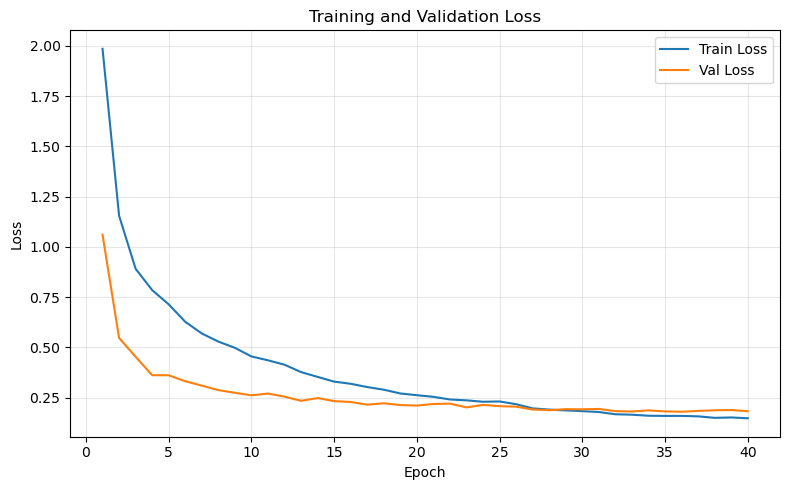

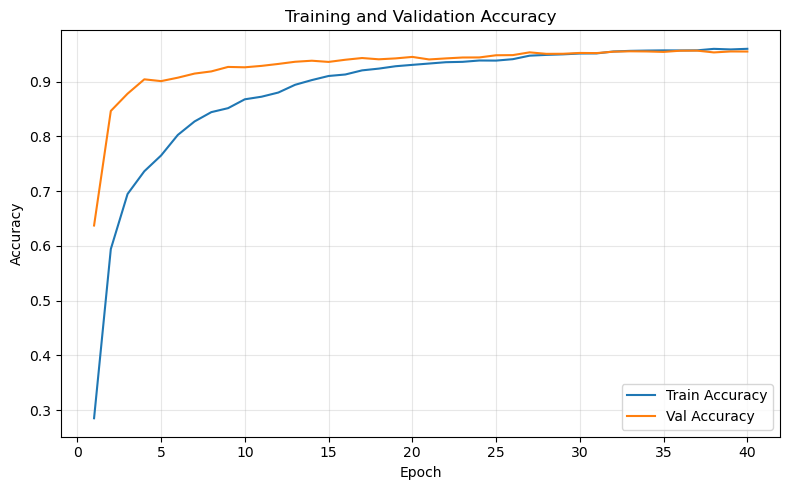

In [34]:
# =========================
# 14. 绘制 Loss / Accuracy 曲线
# =========================

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "loss_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "accuracy_curve.png", dpi=200)
plt.show()

## 6. 在测试集上进行最终评估

根据作业要求，需要给出：
- **测试准确率（Test Accuracy）**
- **训练/测试准确率曲线**
- **训练损失/测试损失曲线**

这里采用验证集损失最优的模型，在测试集上做最终评估。

In [35]:
# =========================
# 15. 加载最优模型并测试
# =========================

best_model = SVHNCNN(num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_acc, y_true, y_pred = evaluate(best_model, test_loader, criterion, DEVICE)

print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Best Validation Loss: 0.1793
Test Loss: 0.1623
Test Accuracy: 0.9620


### 测试结果分析建议
这里建议你从以下几个角度写结果分析：
- 测试准确率是否达到较合理水平；
- 相比训练/验证准确率，测试准确率是否说明模型泛化较好；
- 若准确率偏低，可分析原因：模型容量不足、数据增强不充分、训练轮次偏少等。

In [36]:
# =========================
# 16. 分类报告
# =========================

print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9357    0.9759    0.9554      1744
           1     0.9709    0.9686    0.9698      5099
           2     0.9759    0.9761    0.9760      4149
           3     0.9618    0.9271    0.9442      2882
           4     0.9789    0.9742    0.9766      2523
           5     0.9619    0.9627    0.9623      2384
           6     0.9560    0.9666    0.9613      1977
           7     0.9599    0.9609    0.9604      2019
           8     0.9737    0.9367    0.9549      1660
           9     0.9038    0.9542    0.9283      1595

    accuracy                         0.9620     26032
   macro avg     0.9578    0.9603    0.9589     26032
weighted avg     0.9624    0.9620    0.9621     26032



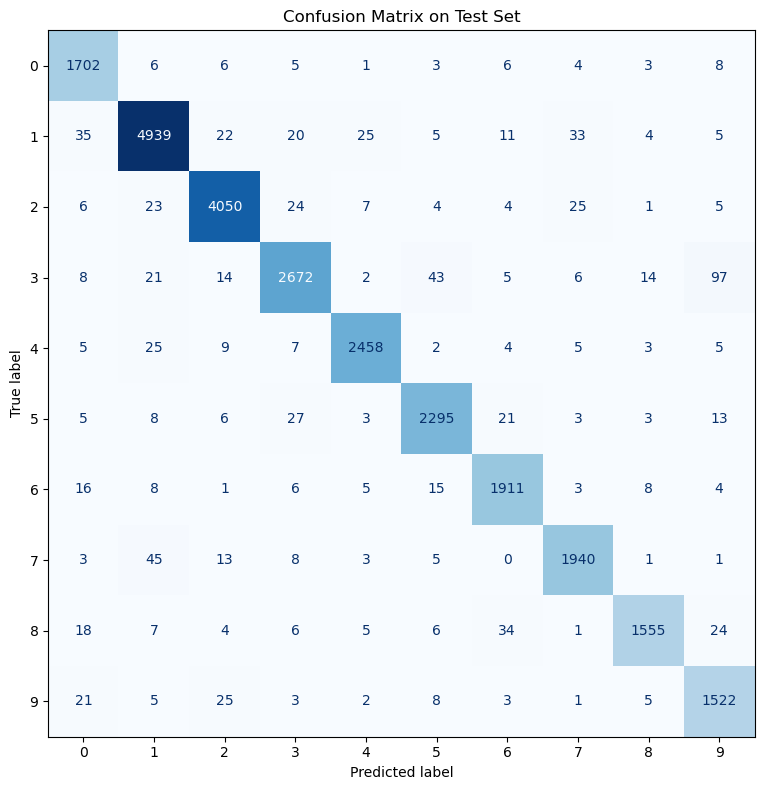

In [37]:
# =========================
# 17. 混淆矩阵
# =========================

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Confusion Matrix on Test Set")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=200)
plt.show()

### 混淆矩阵分析建议
可以重点观察以下问题：
- 哪些数字更容易被混淆，例如 `1` 与 `7`、`5` 与 `6`；
- 错误是否主要出现在视觉形态接近、背景复杂或有残影干扰的样本上；
- 这也说明 SVHN 相较于 MNIST 更接近真实场景任务，分类难度更高。

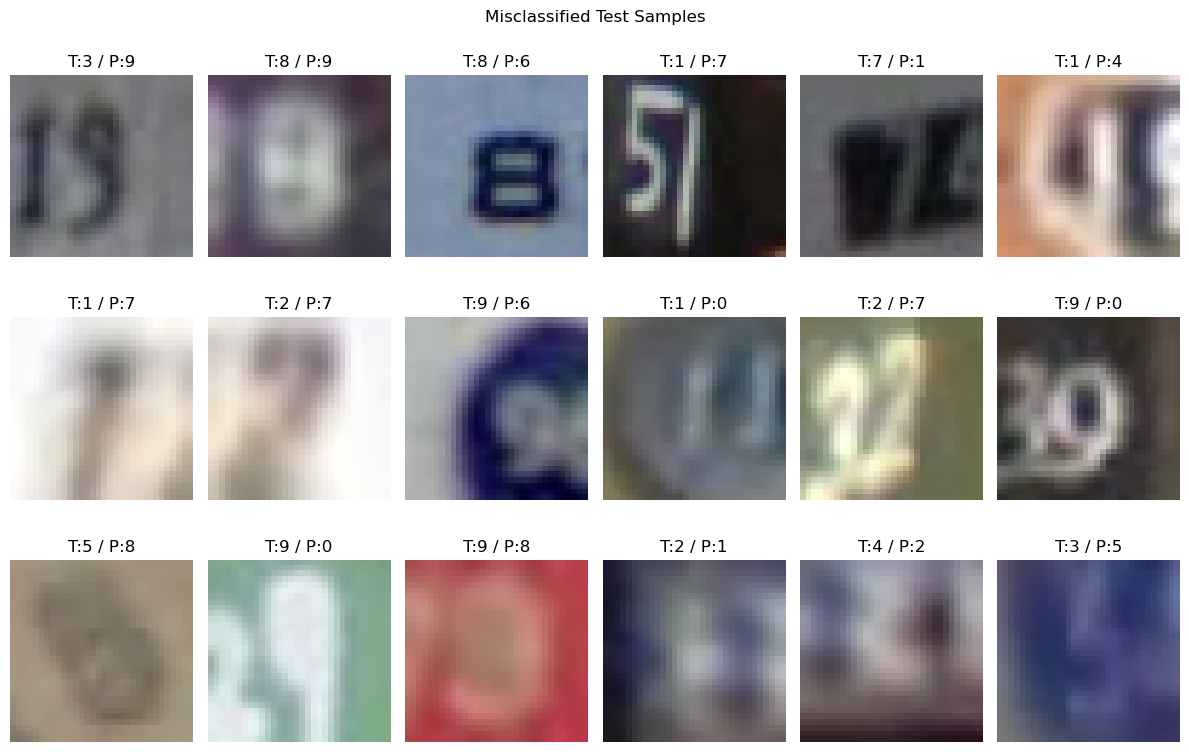

In [38]:
# =========================
# 18. 可视化错分样本
# =========================

@torch.no_grad()
def collect_misclassified_samples(model, dataloader, device, max_samples=24):
    model.eval()
    mis_images, mis_labels, mis_preds = [], [], []

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        wrong_mask = preds != labels
        if wrong_mask.any():
            wrong_images = images[wrong_mask].cpu()
            wrong_labels = labels[wrong_mask].cpu().numpy()
            wrong_preds = preds[wrong_mask].cpu().numpy()

            for img, lab, pred in zip(wrong_images, wrong_labels, wrong_preds):
                mis_images.append(img)
                mis_labels.append(lab)
                mis_preds.append(pred)
                if len(mis_images) >= max_samples:
                    return mis_images, mis_labels, mis_preds

    return mis_images, mis_labels, mis_preds

mis_images, mis_labels, mis_preds = collect_misclassified_samples(best_model, test_loader, DEVICE, max_samples=18)

plt.figure(figsize=(12, 8))
for i, (img, lab, pred) in enumerate(zip(mis_images, mis_labels, mis_preds), 1):
    plt.subplot(3, 6, i)
    img_np = img.permute(1, 2, 0).numpy()
    img_np = img_np * np.array(std) + np.array(mean)
    img_np = np.clip(img_np, 0, 1)
    plt.imshow(img_np)
    plt.title(f"T:{lab} / P:{pred}")
    plt.axis("off")
plt.suptitle("Misclassified Test Samples")
plt.tight_layout()
plt.savefig(FIG_DIR / "misclassified_samples.png", dpi=200)
plt.show()

## 7. 可选升级：更强模型与可拓展方向

在满足作业要求的前提下，还可以进一步提升性能：

### 7.1 模型结构升级
- 使用 ResNet18 / ResNet34
- 使用更深的卷积堆叠
- 引入 SE/CBAM 注意力机制

### 7.2 数据策略升级
- 加入 `extra_32x32.mat`
- 使用 Cutout / Mixup / RandAugment
- 统计训练集真实均值方差并精确标准化

### 7.3 训练策略升级
- 使用 CosineAnnealingLR
- 增加训练轮次
- 使用 Early Stopping
- 使用 Label Smoothing

### 7.4 实验报告升级
- 对比“无增强 / 有增强”
- 对比“基础 CNN / 改进 CNN”
- 对比不同学习率或 batch size 的影响

这些内容不一定都要写进最终提交，但在报告的“改进方向”部分可以简要提及，从而体现更完整的实验思考。

In [39]:
# =========================
# 19. （可选）使用 ResNet18 的示例代码
# =========================
# 如需升级模型，可取消注释并替换原模型。
#
# from torchvision.models import resnet18
#
# class SVHNResNet18(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()
#         self.backbone = resnet18(weights=None)
#         self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
#         self.backbone.maxpool = nn.Identity()
#         self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)
#
#     def forward(self, x):
#         return self.backbone(x)
#
# model = SVHNResNet18(num_classes=10).to(DEVICE)

## 8. 结论写作参考

本实验基于 SVHN Format 2 数据集完成了街景门牌数字分类任务，构建了一个多层卷积神经网络，并通过训练集、验证集和测试集上的实验对模型性能进行了系统评估。结果表明，CNN 能够有效提取数字图像中的局部纹理与结构特征，在 SVHN 这一真实场景数据集上取得较好的分类效果。通过绘制损失曲线与准确率曲线，可以观察模型逐步收敛的过程；结合混淆矩阵与错分样本分析，可以进一步发现模型对形态相近数字和复杂背景样本仍存在一定误判。总体来看，该方法完成了作业要求，后续还可通过更深层网络、数据增强和更优训练策略进一步提升分类性能。

## 9. 导出 PDF 的建议

建议流程：
1. 在本 Notebook 中补充你自己的运行结果截图、实验分析与结论；
2. 确保所有代码单元都已经顺序运行完毕；
3. 使用 Jupyter Notebook / JupyterLab / VS Code 导出为 PDF；
4. 若本机 PDF 导出依赖 LaTeX 环境较麻烦，也可以先导出为 HTML，再在浏览器中“打印为 PDF”。

提交时按题目要求，把：
- 报告 PDF
- 源码（`.ipynb`）

一起打包压缩后发送到助教邮箱。